In [5]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# Charger la base de données dans un DataFrame pandas
data = pd.read_csv('my_data_folder/bdd_utilisable/data_merged_CO2_SL_SST_Ice_Mass_Chlor.csv')


# Nettoyer la colonne 'year_month' pour enlever les jours (par exemple, "-01")
data['year_month'] = data['year_month'].str.slice(0, 7)  # Garder seulement l'année et le mois (YYYY-MM)

# Convertir la colonne 'year_month' en type datetime avec seulement l'année et le mois
data['year_month'] = pd.to_datetime(data['year_month'], format='%Y-%m')

# Afficher les premières lignes du DataFrame pour vérifier la conversion
print(data.head())



  year_month  MSL_filtered_GIA_TPA_corrected_adjusted  chlor_a  \
0 1982-01-01                                      NaN      NaN   
1 1982-02-01                                      NaN      NaN   
2 1982-03-01                                      NaN      NaN   
3 1982-04-01                                      NaN      NaN   
4 1982-05-01                                      NaN      NaN   

   sst_anomaly_filtered  value  greenland_mass_antarctica time  \
0                   NaN    NaN                        NaN  NaN   
1                   NaN    NaN                        NaN  NaN   
2                   NaN    NaN                        NaN  NaN   
3                   NaN    NaN                        NaN  NaN   
4                   NaN    NaN                        NaN  NaN   

   moyenne_variable  
0               NaN  
1               NaN  
2               NaN  
3               NaN  
4               NaN  


In [7]:
# Traitement des valeurs manquantes
print(data.isna().sum())  
print((data == float('inf')).sum())  

data.replace([float('inf'), -float('inf')], float('nan'), inplace=True)

data_clean = data.dropna()

year_month                                   0
MSL_filtered_GIA_TPA_corrected_adjusted    151
chlor_a                                    201
sst_anomaly_filtered                        37
value                                      300
greenland_mass_antarctica                  280
time                                       349
moyenne_variable                           349
dtype: int64
year_month                                 0
MSL_filtered_GIA_TPA_corrected_adjusted    0
chlor_a                                    0
sst_anomaly_filtered                       0
value                                      0
greenland_mass_antarctica                  0
time                                       0
moyenne_variable                           0
dtype: int64


In [11]:
#variables d'intéret et prédictives
Y = data_clean['MSL_filtered_GIA_TPA_corrected_adjusted']
X = data_clean[['chlor_a', 'sst_anomaly_filtered', 'value', 'greenland_mass_antarctica', 'moyenne_variable']]
X = sm.add_constant(X)

#modèle
model = sm.OLS(Y, X)
results = model.fit()

# Résultats
print(results.summary())

                                       OLS Regression Results                                      
Dep. Variable:     MSL_filtered_GIA_TPA_corrected_adjusted   R-squared:                       0.098
Model:                                                 OLS   Adj. R-squared:                  0.060
Method:                                      Least Squares   F-statistic:                     2.573
Date:                                     Wed, 09 Apr 2025   Prob (F-statistic):             0.0301
Time:                                             15:54:51   Log-Likelihood:                -267.84
No. Observations:                                      125   AIC:                             547.7
Df Residuals:                                          119   BIC:                             564.6
Df Model:                                                5                                         
Covariance Type:                                 nonrobust                                         


NameError: name 'plt' is not defined

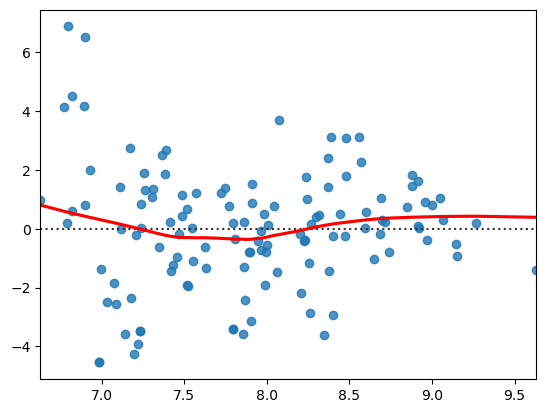

In [14]:
# Visualisation des résultats de la régression

import seaborn as sns

y_pred = results.predict(X)

sns.residplot(x=y_pred, y=Y - y_pred, lowess=True, line_kws={'color': 'red'})
plt.title('Graphique des résidus de la régression')
plt.xlabel('Valeurs prédites')
plt.ylabel('Résidus')
plt.show()

# Tracer la ligne de régression
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([min(y), max(y)], [min(y_pred), max(y_pred)], color='red', linestyle='--')
plt.title('Régression Linéaire Multiple - Prédictions vs Réel')
plt.xlabel('Valeurs réelles')
plt.ylabel('Valeurs prédites')
plt.show()

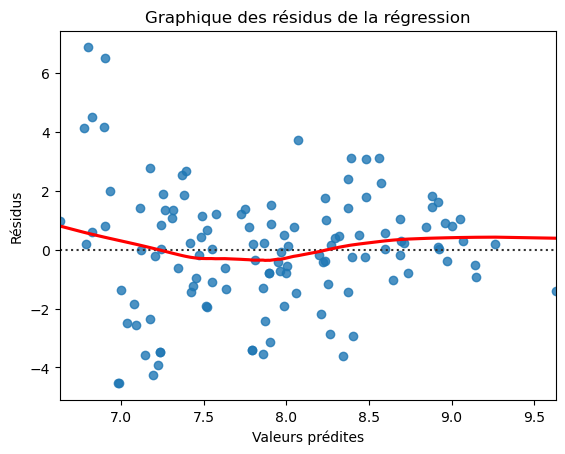

/tmp/ipykernel_117601/2242795532.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = coefficients[0]  # L'ordonnée à l'origine
/tmp/ipykernel_117601/2242795532.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(0.05, 0.85 - (i * 0.05), f'{variable_names[var_name]}: {slope[i]:.2f}', transform=plt.gca().transAxes, fontsize=12, color='green')


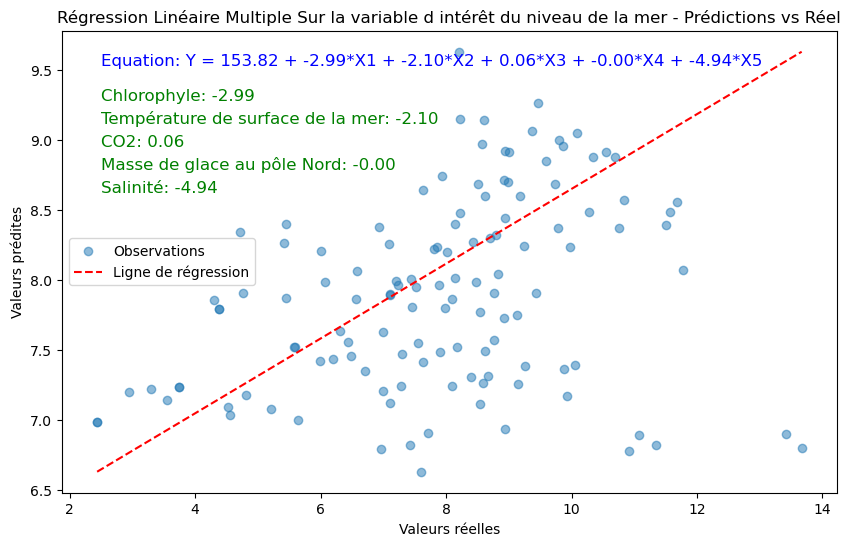

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prédictions du modèle
y_pred = results.predict(X)

# Visualisation des résidus
sns.residplot(x=y_pred, y=Y - y_pred, lowess=True, line_kws={'color': 'red'})
plt.title('Graphique des résidus de la régression')
plt.xlabel('Valeurs prédites')
plt.ylabel('Résidus')
plt.show()